Starting Stock Market Simulation...
Number of Agents: 8
Number of Stocks: 5



STOCK MARKET SIMULATION REPORT

STOCK PERFORMANCE:
----------------------------------------
TECH (Tech Giant Inc.):
  Initial: $150.00
  Final:   $166.70
  Return:  +11.13%
  Volatility: 2.74%
BANK (Global Bank Corp.):
  Initial: $80.00
  Final:   $74.15
  Return:  -7.31%
  Volatility: 2.05%
PHARM (Pharma Innovations):
  Initial: $120.00
  Final:   $120.15
  Return:  +0.13%
  Volatility: 3.84%
AUTO (Auto Manufacturers):
  Initial: $60.00
  Final:   $55.94
  Return:  -6.76%
  Volatility: 2.50%
OIL (Energy Producers):
  Initial: $40.00
  Final:   $46.37
  Return:  +15.92%
  Volatility: 3.29%

AGENT PERFORMANCE:
----------------------------------------

AGENT_001 (RANDOM):
  Final Wealth: $11275.45
  Total Return: +12.75%
  Sharpe Ratio: 0.000
  Cash: $2925.68
  Portfolio Value: $8349.77
  Trades Executed: 659

AGENT_002 (RANDOM):
  Final Wealth: $11631.21
  Total Return: -3.07%
  Sharpe Ratio: 0.000
  Cash: $4585.19
  Portfolio Value: $7046.02
  Trades Executed: 665

AGENT_003 (RANDOM):

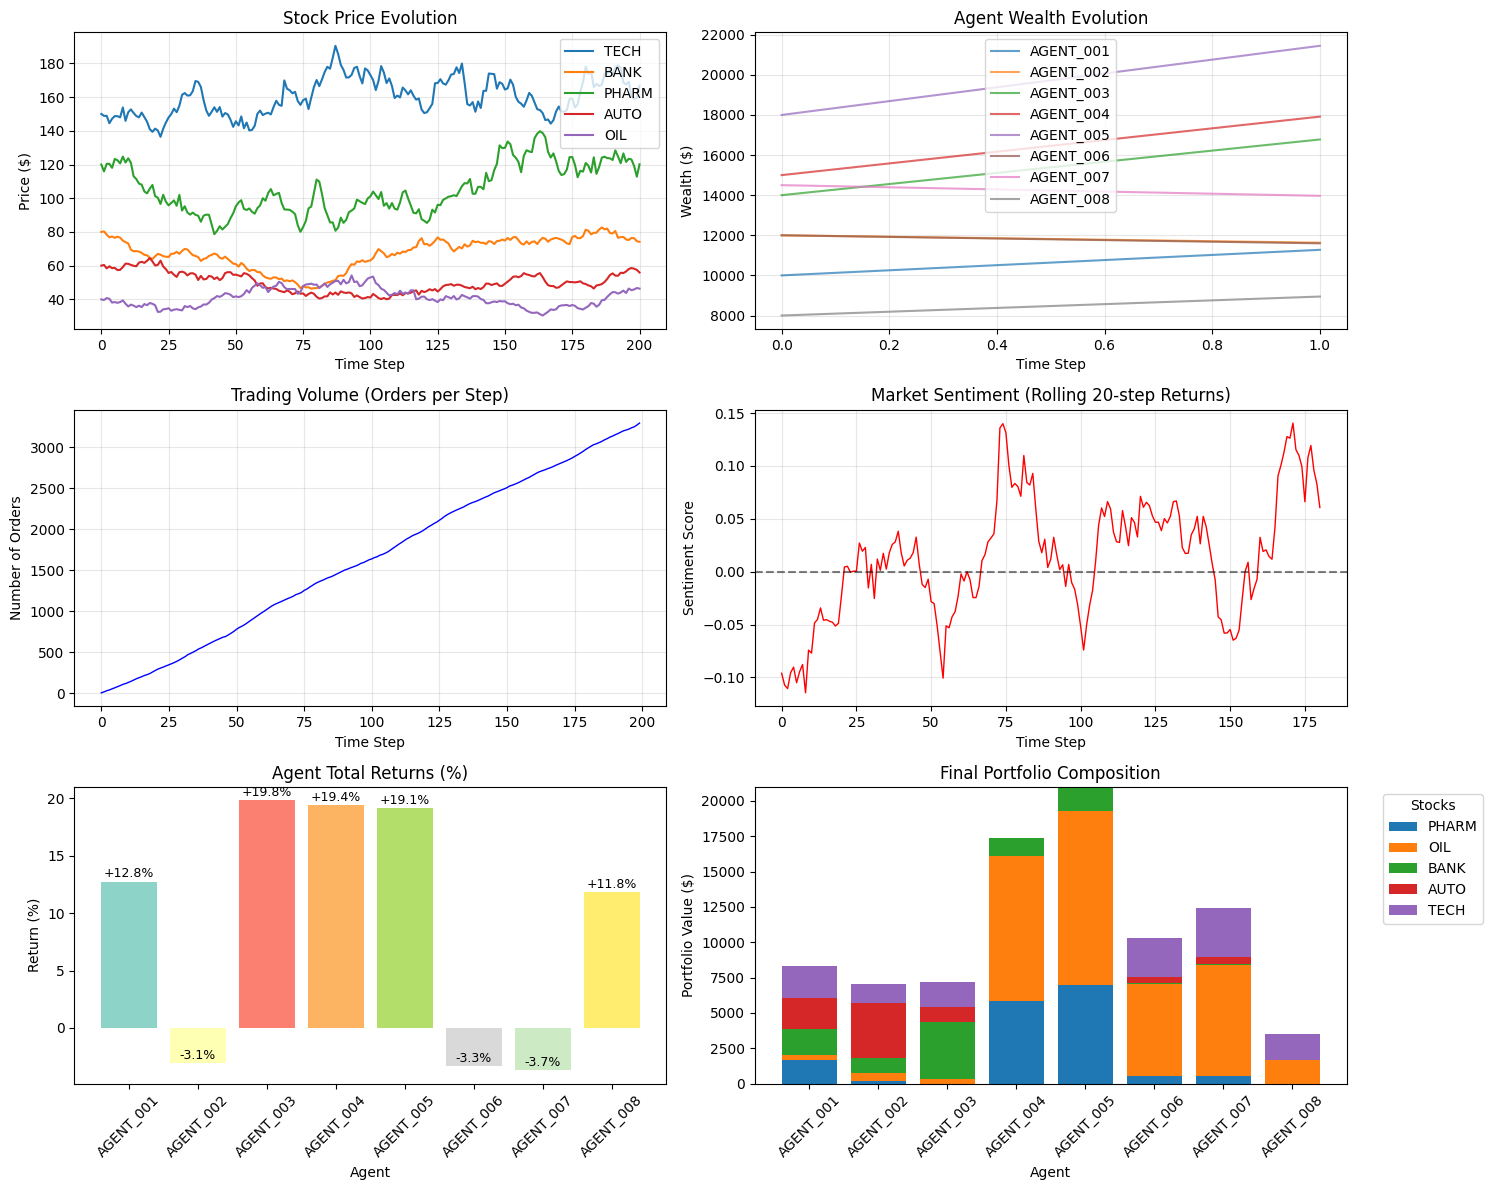

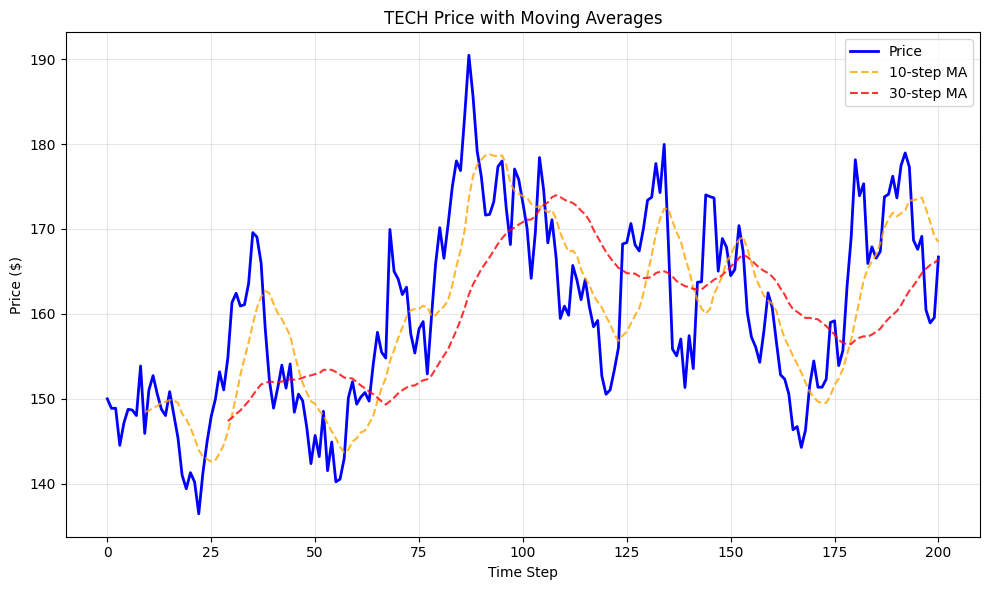


Data exported:
- Stock prices: 201 rows saved to 'stock_prices.csv'
- Agent wealth: 3 rows saved to 'agent_wealth.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import random
import numpy as np
from enum import Enum
from typing import List, Dict, Optional
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from abc import ABC, abstractmethod
import pandas as pd
from datetime import datetime, timedelta
import logging

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Enums
class OrderType(Enum):
    BUY = "BUY"
    SELL = "SELL"
    HOLD = "HOLD"

class AgentType(Enum):
    RANDOM = "RANDOM"
    MEAN_REVERSION = "MEAN_REVERSION"
    TREND_FOLLOWER = "TREND_FOLLOWER"
    NOISE = "NOISE"

class OrderStatus(Enum):
    PENDING = "PENDING"
    EXECUTED = "EXECUTED"
    CANCELLED = "CANCELLED"

# Trading Signal class
class TradingSignal:
    def __init__(self, signal_type: OrderType, confidence: float = 0.5):
        self.signal_type = signal_type
        self.confidence = confidence

    def __str__(self):
        return f"{self.signal_type.value} (Confidence: {self.confidence:.2f})"

# Market Data Container
class MarketData:
    def __init__(self):
        self.stock_prices: Dict[str, float] = {}
        self.price_histories: Dict[str, List[float]] = {}
        self.moving_averages: Dict[str, float] = {}
        self.volatility: Dict[str, float] = {}
        self.timestamp = 0

    def update_prices(self, new_prices: Dict[str, float]):
        """Update market prices and maintain history"""
        for symbol, price in new_prices.items():
            self.stock_prices[symbol] = price
            if symbol not in self.price_histories:
                self.price_histories[symbol] = []
            self.price_histories[symbol].append(price)

            # Keep only last 100 prices
            if len(self.price_histories[symbol]) > 100:
                self.price_histories[symbol] = self.price_histories[symbol][-100:]

        self.timestamp += 1

    def calculate_moving_average(self, symbol: str, window: int = 10) -> float:
        """Calculate moving average for a stock"""
        if symbol in self.price_histories and len(self.price_histories[symbol]) >= window:
            prices = self.price_histories[symbol][-window:]
            self.moving_averages[symbol] = sum(prices) / len(prices)
            return self.moving_averages[symbol]
        return 0.0

    def calculate_volatility(self, symbol: str, window: int = 20) -> float:
        """Calculate volatility (standard deviation) for a stock"""
        if symbol in self.price_histories and len(self.price_histories[symbol]) >= window:
            prices = self.price_histories[symbol][-window:]
            returns = np.diff(prices) / prices[:-1]
            self.volatility[symbol] = np.std(returns) if len(returns) > 0 else 0.0
            return self.volatility[symbol]
        return 0.0

    def get_stock_price(self, symbol: str) -> float:
        """Get current price of a stock"""
        return self.stock_prices.get(symbol, 0.0)

    def get_price_history(self, symbol: str) -> List[float]:
        """Get price history of a stock"""
        return self.price_histories.get(symbol, [])

# Stock Class
class Stock:
    def __init__(self, symbol: str, name: str, initial_price: float, volatility: float = 0.02):
        self.symbol = symbol
        self.name = name
        self.current_price = initial_price
        self.base_price = initial_price
        self.volatility = volatility
        self.price_history = [initial_price]

    def update_price(self, market_sentiment: float = 0.0):
        """Update stock price using geometric Brownian motion"""
        # Random walk with drift
        drift = 0.0001  # Small positive drift
        random_shock = np.random.normal(0, self.volatility)

        # Update price: P_t = P_{t-1} * exp(drift + random_shock + sentiment)
        price_change = drift + random_shock + (market_sentiment * 0.001)
        self.current_price *= np.exp(price_change)

        # Add some mean reversion
        reversion_strength = 0.01
        self.current_price = self.current_price * (1 - reversion_strength) + self.base_price * reversion_strength

        # Ensure price doesn't go negative
        self.current_price = max(0.01, self.current_price)

        self.price_history.append(self.current_price)

        # Keep history manageable
        if len(self.price_history) > 1000:
            self.price_history = self.price_history[-1000:]

        return self.current_price

    def get_price(self) -> float:
        return self.current_price

# Trading Strategy Interface
class TradingStrategy(ABC):
    @abstractmethod
    def generate_signal(self, stock: Stock, market_data: MarketData) -> TradingSignal:
        pass

    @abstractmethod
    def calculate_order(self, stock: Stock, agent: 'StockAgent', market_data: MarketData) -> Optional['Order']:
        pass

# Concrete Strategy Implementations
class RandomTradingStrategy(TradingStrategy):
    def generate_signal(self, stock: Stock, market_data: MarketData) -> TradingSignal:
        """Generate random trading signal"""
        rand = random.random()
        if rand < 0.4:
            return TradingSignal(OrderType.BUY, random.uniform(0.3, 0.7))
        elif rand < 0.7:
            return TradingSignal(OrderType.SELL, random.uniform(0.3, 0.7))
        else:
            return TradingSignal(OrderType.HOLD, random.uniform(0.5, 0.9))

    def calculate_order(self, stock: Stock, agent: 'StockAgent', market_data: MarketData) -> Optional['Order']:
        signal = self.generate_signal(stock, market_data)

        if signal.signal_type == OrderType.HOLD:
            return None

        price = stock.get_price()
        cash_available = agent.cash
        current_holding = agent.portfolio.get(stock.symbol, 0)

        if signal.signal_type == OrderType.BUY and cash_available > price:
            max_shares = int(cash_available * 0.2 / price)  # Use 20% of cash
            quantity = random.randint(1, max(1, max_shares))
            return Order(agent.agent_id, stock.symbol, OrderType.BUY, quantity, price)

        elif signal.signal_type == OrderType.SELL and current_holding > 0:
            quantity = random.randint(1, current_holding)
            return Order(agent.agent_id, stock.symbol, OrderType.SELL, quantity, price)

        return None

class MeanReversionStrategy(TradingStrategy):
    def __init__(self, lookback_period: int = 20, threshold: float = 1.5):
        self.lookback_period = lookback_period
        self.threshold = threshold

    def generate_signal(self, stock: Stock, market_data: MarketData) -> TradingSignal:
        prices = market_data.get_price_history(stock.symbol)

        if len(prices) < self.lookback_period:
            return TradingSignal(OrderType.HOLD, 0.5)

        current_price = stock.get_price()
        avg_price = np.mean(prices[-self.lookback_period:])
        std_price = np.std(prices[-self.lookback_period:]) if len(prices) > 1 else 1.0

        z_score = (current_price - avg_price) / std_price if std_price > 0 else 0

        if z_score < -self.threshold:
            confidence = min(0.9, abs(z_score) / (2 * self.threshold))
            return TradingSignal(OrderType.BUY, confidence)
        elif z_score > self.threshold:
            confidence = min(0.9, abs(z_score) / (2 * self.threshold))
            return TradingSignal(OrderType.SELL, confidence)
        else:
            return TradingSignal(OrderType.HOLD, 0.5)

    def calculate_order(self, stock: Stock, agent: 'StockAgent', market_data: MarketData) -> Optional['Order']:
        signal = self.generate_signal(stock, market_data)

        if signal.signal_type == OrderType.HOLD:
            return None

        price = stock.get_price()
        cash_available = agent.cash
        current_holding = agent.portfolio.get(stock.symbol, 0)

        if signal.signal_type == OrderType.BUY and cash_available > price:
            quantity = int(min(cash_available * 0.3, cash_available * signal.confidence) / price)
            quantity = max(1, quantity)
            return Order(agent.agent_id, stock.symbol, OrderType.BUY, quantity, price)

        elif signal.signal_type == OrderType.SELL and current_holding > 0:
            quantity = int(current_holding * signal.confidence)
            quantity = max(1, quantity)
            return Order(agent.agent_id, stock.symbol, OrderType.SELL, quantity, price)

        return None

class TrendFollowingStrategy(TradingStrategy):
    def __init__(self, short_window: int = 10, long_window: int = 30):
        self.short_window = short_window
        self.long_window = long_window

    def generate_signal(self, stock: Stock, market_data: MarketData) -> TradingSignal:
        prices = market_data.get_price_history(stock.symbol)

        if len(prices) < self.long_window:
            return TradingSignal(OrderType.HOLD, 0.5)

        short_ma = np.mean(prices[-self.short_window:])
        long_ma = np.mean(prices[-self.long_window:])

        # Calculate trend strength
        trend_strength = abs(short_ma - long_ma) / long_ma

        if short_ma > long_ma * 1.01:  # Uptrend
            confidence = min(0.9, trend_strength * 10)
            return TradingSignal(OrderType.BUY, confidence)
        elif short_ma < long_ma * 0.99:  # Downtrend
            confidence = min(0.9, trend_strength * 10)
            return TradingSignal(OrderType.SELL, confidence)
        else:
            return TradingSignal(OrderType.HOLD, 0.5)

    def calculate_order(self, stock: Stock, agent: 'StockAgent', market_data: MarketData) -> Optional['Order']:
        signal = self.generate_signal(stock, market_data)

        if signal.signal_type == OrderType.HOLD:
            return None

        price = stock.get_price()
        cash_available = agent.cash
        current_holding = agent.portfolio.get(stock.symbol, 0)

        if signal.signal_type == OrderType.BUY and cash_available > price:
            quantity = int(min(cash_available * 0.4, cash_available * signal.confidence) / price)
            quantity = max(1, quantity)
            return Order(agent.agent_id, stock.symbol, OrderType.BUY, quantity, price)

        elif signal.signal_type == OrderType.SELL and current_holding > 0:
            quantity = int(current_holding * signal.confidence)
            quantity = max(1, quantity)
            return Order(agent.agent_id, stock.symbol, OrderType.SELL, quantity, price)

        return None

# Order Class
class Order:
    order_counter = 0

    def __init__(self, agent_id: str, stock_symbol: str, order_type: OrderType,
                 quantity: int, price: float):
        Order.order_counter += 1
        self.order_id = f"ORD_{Order.order_counter:06d}"
        self.agent_id = agent_id
        self.stock_symbol = stock_symbol
        self.order_type = order_type
        self.quantity = quantity
        self.price = price
        self.status = OrderStatus.PENDING
        self.timestamp = datetime.now()

    def execute(self, market_price: float) -> bool:
        """Execute the order at market price"""
        try:
            if self.status == OrderStatus.PENDING:
                self.price = market_price  # Update to actual execution price
                self.status = OrderStatus.EXECUTED
                logger.debug(f"Order {self.order_id} executed at {market_price:.2f}")
                return True
            return False
        except Exception as e:
            logger.error(f"Failed to execute order {self.order_id}: {e}")
            return False

    def __str__(self):
        return f"Order {self.order_id}: {self.order_type.value} {self.quantity} {self.stock_symbol} @ {self.price:.2f}"

# Stock Agent Class
class StockAgent:
    agent_counter = 0

    def __init__(self, agent_type: AgentType, initial_cash: float = 10000.0):
        StockAgent.agent_counter += 1
        self.agent_id = f"AGENT_{StockAgent.agent_counter:03d}"
        self.agent_type = agent_type
        self.cash = initial_cash
        self.initial_cash = initial_cash
        self.portfolio: Dict[str, int] = {}  # symbol -> quantity
        self.order_history: List[Order] = []
        self.wealth_history: List[float] = [initial_cash]

        # Assign strategy based on agent type
        if agent_type == AgentType.RANDOM:
            self.strategy = RandomTradingStrategy()
        elif agent_type == AgentType.MEAN_REVERSION:
            self.strategy = MeanReversionStrategy()
        elif agent_type == AgentType.TREND_FOLLOWER:
            self.strategy = TrendFollowingStrategy()
        else:
            self.strategy = RandomTradingStrategy()

    def execute_trading_actions(self, stocks: List[Stock], market_data: MarketData) -> List[Order]:
        """Execute trading actions based on strategy"""
        orders = []

        for stock in stocks:
            try:
                order = self.strategy.calculate_order(stock, self, market_data)
                if order:
                    orders.append(order)
            except Exception as e:
                logger.error(f"Agent {self.agent_id} error trading {stock.symbol}: {e}")

        return orders

    def update_portfolio(self, stock_symbol: str, quantity: int, price: float, is_buy: bool):
        """Update portfolio after trade execution"""
        try:
            if is_buy:
                # Buy order
                total_cost = quantity * price
                if self.cash >= total_cost:
                    self.cash -= total_cost
                    self.portfolio[stock_symbol] = self.portfolio.get(stock_symbol, 0) + quantity
                    logger.debug(f"Agent {self.agent_id} bought {quantity} {stock_symbol} @ {price:.2f}")
                else:
                    logger.warning(f"Agent {self.agent_id} insufficient cash to buy")
            else:
                # Sell order
                current_holding = self.portfolio.get(stock_symbol, 0)
                if current_holding >= quantity:
                    self.cash += quantity * price
                    self.portfolio[stock_symbol] = current_holding - quantity
                    if self.portfolio[stock_symbol] == 0:
                        del self.portfolio[stock_symbol]
                    logger.debug(f"Agent {self.agent_id} sold {quantity} {stock_symbol} @ {price:.2f}")
                else:
                    logger.warning(f"Agent {self.agent_id} insufficient shares to sell")
        except Exception as e:
            logger.error(f"Error updating portfolio for agent {self.agent_id}: {e}")

    def get_wealth(self, market_data: MarketData) -> float:
        """Calculate total wealth (cash + portfolio value)"""
        portfolio_value = 0.0
        for symbol, quantity in self.portfolio.items():
            current_price = market_data.get_stock_price(symbol)
            portfolio_value += quantity * current_price

        total_wealth = self.cash + portfolio_value
        self.wealth_history.append(total_wealth)

        # Keep history manageable
        if len(self.wealth_history) > 1000:
            self.wealth_history = self.wealth_history[-1000:]

        return total_wealth

    def get_performance_metrics(self, market_data: MarketData) -> Dict:
        """Calculate performance metrics"""
        current_wealth = self.get_wealth(market_data)
        total_return = (current_wealth - self.initial_cash) / self.initial_cash * 100

        returns = []
        for i in range(1, len(self.wealth_history)):
            if self.wealth_history[i-1] > 0:
                ret = (self.wealth_history[i] - self.wealth_history[i-1]) / self.wealth_history[i-1]
                returns.append(ret)

        sharpe_ratio = 0.0
        if returns:
            avg_return = np.mean(returns)
            std_return = np.std(returns)
            if std_return > 0:
                sharpe_ratio = avg_return / std_return * np.sqrt(252)  # Annualized

        return {
            "agent_id": self.agent_id,
            "agent_type": self.agent_type.value,
            "current_wealth": current_wealth,
            "total_return_pct": total_return,
            "cash": self.cash,
            "portfolio_value": current_wealth - self.cash,
            "sharpe_ratio": sharpe_ratio,
            "num_trades": len(self.order_history)
        }

    def __str__(self):
        return f"{self.agent_id} ({self.agent_type.value}): Cash=${self.cash:.2f}, Holdings={self.portfolio}"

# Main Simulator Class
class StockMarketSimulator:
    def __init__(self, initial_cash_per_agent: float = 10000.0):
        self.agents: List[StockAgent] = []
        self.stocks: List[Stock] = []
        self.market_data = MarketData()
        self.current_step = 0
        self.order_book: List[Order] = []
        self.executed_orders: List[Order] = []
        self.market_sentiment = 0.0
        self.trading_volume = []
        self.price_history = {}

    def add_stock(self, stock: Stock):
        """Add a stock to the market"""
        self.stocks.append(stock)
        self.market_data.stock_prices[stock.symbol] = stock.current_price
        self.market_data.price_histories[stock.symbol] = [stock.current_price]
        self.price_history[stock.symbol] = [stock.current_price]

    def add_agent(self, agent_type: AgentType, initial_cash: float = None):
        """Add an agent to the market"""
        if initial_cash is None:
            initial_cash = 10000.0
        agent = StockAgent(agent_type, initial_cash)
        self.agents.append(agent)
        logger.info(f"Added agent: {agent}")

    def run_step(self):
        """Run one simulation step"""
        self.current_step += 1

        # Update stock prices
        new_prices = {}
        for stock in self.stocks:
            # Add some market sentiment influence
            new_price = stock.update_price(self.market_sentiment)
            new_prices[stock.symbol] = new_price
            self.price_history[stock.symbol].append(new_price)

        self.market_data.update_prices(new_prices)

        # Calculate market sentiment based on recent price movements
        self._update_market_sentiment()

        # Clear previous orders
        self.order_book = []

        # Agents generate orders
        for agent in self.agents:
            orders = agent.execute_trading_actions(self.stocks, self.market_data)
            self.order_book.extend(orders)

        # Execute orders
        self._execute_orders()

        # Update trading volume
        volume = len([o for o in self.executed_orders if o.timestamp.date() == datetime.now().date()])
        self.trading_volume.append(volume)

        logger.debug(f"Step {self.current_step}: {len(self.executed_orders)} orders executed")

    def _update_market_sentiment(self):
        """Update overall market sentiment"""
        if self.current_step < 10:
            self.market_sentiment = 0.0
            return

        # Calculate sentiment based on recent price changes
        sentiment_score = 0.0
        for stock in self.stocks:
            prices = self.market_data.get_price_history(stock.symbol)
            if len(prices) >= 5:
                recent_change = (prices[-1] - prices[-5]) / prices[-5]
                sentiment_score += recent_change

        # Normalize and smooth sentiment
        avg_sentiment = sentiment_score / len(self.stocks) if self.stocks else 0.0
        self.market_sentiment = 0.7 * self.market_sentiment + 0.3 * avg_sentiment

        # Add some random noise
        self.market_sentiment += np.random.normal(0, 0.1)

        # Bound sentiment
        self.market_sentiment = max(-1.0, min(1.0, self.market_sentiment))

    def _execute_orders(self):
        """Execute all pending orders"""
        executed_today = []

        for order in self.order_book:
            if order.status == OrderStatus.PENDING:
                stock = next((s for s in self.stocks if s.symbol == order.stock_symbol), None)
                if stock:
                    market_price = stock.get_price()

                    # Add small spread and slippage
                    execution_price = market_price * (1 + np.random.normal(0, 0.001))

                    if order.execute(execution_price):
                        # Find the agent
                        agent = next((a for a in self.agents if a.agent_id == order.agent_id), None)
                        if agent:
                            is_buy = order.order_type == OrderType.BUY
                            agent.update_portfolio(order.stock_symbol, order.quantity, execution_price, is_buy)
                            agent.order_history.append(order)
                            executed_today.append(order)

        self.executed_orders.extend(executed_today)

        # Keep only recent orders for memory management
        if len(self.executed_orders) > 10000:
            self.executed_orders = self.executed_orders[-5000:]

    def run_simulation(self, steps: int = 100):
        """Run simulation for specified number of steps"""
        logger.info(f"Starting simulation for {steps} steps")

        for step in range(steps):
            if step % 10 == 0:
                logger.info(f"Running step {step + 1}/{steps}")

            self.run_step()

            # Periodically log market status
            if step % 50 == 0:
                self._log_market_status()

        logger.info(f"Simulation completed after {steps} steps")
        self._generate_report()

    def _log_market_status(self):
        """Log current market status"""
        logger.info(f"\n=== Market Status at Step {self.current_step} ===")

        # Stock prices
        for stock in self.stocks:
            price = stock.get_price()
            change_pct = ((price / stock.base_price) - 1) * 100
            logger.info(f"{stock.symbol}: ${price:.2f} ({change_pct:+.2f}%)")

        # Market sentiment
        logger.info(f"Market Sentiment: {self.market_sentiment:.3f}")

        # Trading volume
        recent_volume = sum(self.trading_volume[-10:]) if self.trading_volume else 0
        logger.info(f"Recent Trading Volume: {recent_volume} orders")

    def _generate_report(self):
        """Generate simulation report"""
        print("\n" + "="*60)
        print("STOCK MARKET SIMULATION REPORT")
        print("="*60)

        # Stock Performance
        print("\nSTOCK PERFORMANCE:")
        print("-"*40)
        for stock in self.stocks:
            initial_price = stock.base_price
            final_price = stock.get_price()
            total_return = ((final_price / initial_price) - 1) * 100
            volatility = np.std(np.diff(stock.price_history) / stock.price_history[:-1]) * 100 if len(stock.price_history) > 1 else 0

            print(f"{stock.symbol} ({stock.name}):")
            print(f"  Initial: ${initial_price:.2f}")
            print(f"  Final:   ${final_price:.2f}")
            print(f"  Return:  {total_return:+.2f}%")
            print(f"  Volatility: {volatility:.2f}%")

        # Agent Performance
        print("\nAGENT PERFORMANCE:")
        print("-"*40)
        agent_performance = []
        for agent in self.agents:
            metrics = agent.get_performance_metrics(self.market_data)
            agent_performance.append(metrics)

            print(f"\n{agent.agent_id} ({agent.agent_type.value}):")
            print(f"  Final Wealth: ${metrics['current_wealth']:.2f}")
            print(f"  Total Return: {metrics['total_return_pct']:+.2f}%")
            print(f"  Sharpe Ratio: {metrics['sharpe_ratio']:.3f}")
            print(f"  Cash: ${metrics['cash']:.2f}")
            print(f"  Portfolio Value: ${metrics['portfolio_value']:.2f}")
            print(f"  Trades Executed: {metrics['num_trades']}")

        # Market Statistics
        print("\nMARKET STATISTICS:")
        print("-"*40)
        total_volume = len(self.executed_orders)
        avg_daily_volume = np.mean(self.trading_volume) if self.trading_volume else 0
        print(f"Total Trading Volume: {total_volume} orders")
        print(f"Average Daily Volume: {avg_daily_volume:.1f} orders")
        print(f"Market Sentiment: {self.market_sentiment:.3f}")
        print(f"Simulation Steps: {self.current_step}")

        # Find best performing agent
        if agent_performance:
            best_agent = max(agent_performance, key=lambda x: x['total_return_pct'])
            print(f"\nBest Performing Agent: {best_agent['agent_id']} ({best_agent['agent_type']})")
            print(f"Return: {best_agent['total_return_pct']:+.2f}%")

    def visualize_results(self):
        """Visualize simulation results"""
        fig, axes = plt.subplots(3, 2, figsize=(15, 12))

        # Stock price evolution
        ax1 = axes[0, 0]
        for stock in self.stocks:
            prices = stock.price_history
            ax1.plot(prices, label=stock.symbol)
        ax1.set_title('Stock Price Evolution')
        ax1.set_xlabel('Time Step')
        ax1.set_ylabel('Price ($)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Agent wealth evolution
        ax2 = axes[0, 1]
        for agent in self.agents:
            wealth_history = agent.wealth_history
            ax2.plot(wealth_history, label=agent.agent_id, alpha=0.7)
        ax2.set_title('Agent Wealth Evolution')
        ax2.set_xlabel('Time Step')
        ax2.set_ylabel('Wealth ($)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # Trading volume
        ax3 = axes[1, 0]
        ax3.plot(self.trading_volume, color='blue', linewidth=1)
        ax3.set_title('Trading Volume (Orders per Step)')
        ax3.set_xlabel('Time Step')
        ax3.set_ylabel('Number of Orders')
        ax3.grid(True, alpha=0.3)

        # Market sentiment
        ax4 = axes[1, 1]
        # Calculate rolling sentiment
        sentiment_series = []
        for i, stock in enumerate(self.stocks):
            prices = stock.price_history
            if len(prices) >= 20:
                rolling_returns = [(prices[j] - prices[j-20]) / prices[j-20]
                                 for j in range(20, len(prices))]
                sentiment_series.append(rolling_returns)

        if sentiment_series:
            avg_sentiment = np.mean(sentiment_series, axis=0) if sentiment_series else []
            ax4.plot(avg_sentiment, color='red', linewidth=1)
            ax4.axhline(y=0, color='black', linestyle='--', alpha=0.5)
            ax4.set_title('Market Sentiment (Rolling 20-step Returns)')
            ax4.set_xlabel('Time Step')
            ax4.set_ylabel('Sentiment Score')
            ax4.grid(True, alpha=0.3)

        # Agent returns distribution
        ax5 = axes[2, 0]
        returns = []
        labels = []
        for agent in self.agents:
            metrics = agent.get_performance_metrics(self.market_data)
            returns.append(metrics['total_return_pct'])
            labels.append(agent.agent_id)

        colors = plt.cm.Set3(np.linspace(0, 1, len(returns)))
        bars = ax5.bar(labels, returns, color=colors)
        ax5.set_title('Agent Total Returns (%)')
        ax5.set_xlabel('Agent')
        ax5.set_ylabel('Return (%)')
        ax5.tick_params(axis='x', rotation=45)

        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax5.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{height:+.1f}%', ha='center', va='bottom', fontsize=9)

        # Final portfolio composition for each agent
        ax6 = axes[2, 1]
        portfolio_data = []
        agent_labels = []
        stock_labels = list(set([stock.symbol for stock in self.stocks]))

        for agent in self.agents:
            agent_labels.append(agent.agent_id)
            portfolio_values = []
            for stock in self.stocks:
                quantity = agent.portfolio.get(stock.symbol, 0)
                value = quantity * stock.get_price()
                portfolio_values.append(value)
            portfolio_data.append(portfolio_values)

        if portfolio_data:
            portfolio_data = np.array(portfolio_data)
            bottom = np.zeros(len(agent_labels))

            for i, stock in enumerate(stock_labels):
                values = portfolio_data[:, i]
                ax6.bar(agent_labels, values, bottom=bottom, label=stock)
                bottom += values

            ax6.set_title('Final Portfolio Composition')
            ax6.set_xlabel('Agent')
            ax6.set_ylabel('Portfolio Value ($)')
            ax6.tick_params(axis='x', rotation=45)
            ax6.legend(title='Stocks', bbox_to_anchor=(1.05, 1), loc='upper left')

        plt.tight_layout()
        plt.show()

        # Additional visualization: Price chart with moving averages
        if self.stocks:
            fig2, ax = plt.subplots(figsize=(10, 6))
            stock = self.stocks[0]  # Show first stock

            prices = stock.price_history
            ax.plot(prices, label='Price', color='blue', linewidth=2)

            # Calculate and plot moving averages
            if len(prices) >= 20:
                ma_short = pd.Series(prices).rolling(window=10).mean()
                ma_long = pd.Series(prices).rolling(window=30).mean()
                ax.plot(ma_short, label='10-step MA', color='orange', linestyle='--', alpha=0.8)
                ax.plot(ma_long, label='30-step MA', color='red', linestyle='--', alpha=0.8)

            ax.set_title(f'{stock.symbol} Price with Moving Averages')
            ax.set_xlabel('Time Step')
            ax.set_ylabel('Price ($)')
            ax.legend()
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

# Example Usage and Test
def main():
    """Main function to run the simulation"""

    # Create simulator
    simulator = StockMarketSimulator()

    # Add stocks
    simulator.add_stock(Stock("TECH", "Tech Giant Inc.", 150.0, 0.03))
    simulator.add_stock(Stock("BANK", "Global Bank Corp.", 80.0, 0.02))
    simulator.add_stock(Stock("PHARM", "Pharma Innovations", 120.0, 0.04))
    simulator.add_stock(Stock("AUTO", "Auto Manufacturers", 60.0, 0.025))
    simulator.add_stock(Stock("OIL", "Energy Producers", 40.0, 0.035))

    # Add different types of agents
    # Random traders
    for i in range(3):
        simulator.add_agent(AgentType.RANDOM, initial_cash=10000 + i*2000)

    # Mean reversion traders
    for i in range(2):
        simulator.add_agent(AgentType.MEAN_REVERSION, initial_cash=15000 + i*3000)

    # Trend followers
    for i in range(2):
        simulator.add_agent(AgentType.TREND_FOLLOWER, initial_cash=12000 + i*2500)

    # Noise traders (use random strategy but labeled differently)
    for i in range(1):
        simulator.add_agent(AgentType.NOISE, initial_cash=8000)

    # Run simulation
    print("Starting Stock Market Simulation...")
    print(f"Number of Agents: {len(simulator.agents)}")
    print(f"Number of Stocks: {len(simulator.stocks)}")

    try:
        simulator.run_simulation(steps=200)

        # Visualize results
        simulator.visualize_results()

        # Export data for further analysis
        export_simulation_data(simulator)

    except Exception as e:
        logger.error(f"Simulation error: {e}")
        import traceback
        traceback.print_exc()

def export_simulation_data(simulator: StockMarketSimulator):
    """Export simulation data for analysis"""

    # Create DataFrame for stock prices
    stock_data = {}
    for stock in simulator.stocks:
        stock_data[stock.symbol] = stock.price_history

    # Pad with NaN to make equal length
    max_len = max(len(prices) for prices in stock_data.values())
    for symbol in stock_data:
        if len(stock_data[symbol]) < max_len:
            stock_data[symbol] = stock_data[symbol] + [np.nan] * (max_len - len(stock_data[symbol]))

    df_prices = pd.DataFrame(stock_data)
    df_prices.index.name = 'TimeStep'

    # Create DataFrame for agent wealth
    wealth_data = {}
    for agent in simulator.agents:
        wealth_data[agent.agent_id] = agent.wealth_history

    # Pad with NaN
    max_len = max(len(wealth) for wealth in wealth_data.values())
    for agent_id in wealth_data:
        if len(wealth_data[agent_id]) < max_len:
            wealth_data[agent_id] = wealth_data[agent_id] + [np.nan] * (max_len - len(wealth_data[agent_id]))

    df_wealth = pd.DataFrame(wealth_data)
    df_wealth.index.name = 'TimeStep'

    # Export to CSV
    df_prices.to_csv('stock_prices.csv')
    df_wealth.to_csv('agent_wealth.csv')

    print(f"\nData exported:")
    print(f"- Stock prices: {len(df_prices)} rows saved to 'stock_prices.csv'")
    print(f"- Agent wealth: {len(df_wealth)} rows saved to 'agent_wealth.csv'")

    # ADD THIS FOR GOOGLE COLAB:
    from google.colab import files

    # Download the files
    files.download('stock_prices.csv')
    files.download('agent_wealth.csv')

    return df_prices, df_wealth

if __name__ == "__main__":
    main()